In [ ]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib.ticker import PercentFormatter


DATA_DIR = Path('../data')

In [68]:
# from osf import sync_osf
# csv_files = sync_osf(DATA_DIR / "raw")

In [69]:
csv_files = glob.glob(f'{DATA_DIR}/raw/*.csv')

In [70]:
sessions = [pd.read_csv(f) for f in csv_files]
kept_columns = ['random_id', 'chunk_length', 'chunk', 'rt', 'round_index', 'bot_move', 'player_move', 'policy_phase', 'outcome']
valid_sessions = []

for df_tidy, fname in zip(sessions, csv_files):
    scored_rounds = df_tidy.loc[(df_tidy['task_phase'] == 'rps') & (df_tidy['practice'] == False)]
    if scored_rounds.shape[0] < 100:
        print(f'Skipping {fname}')
        continue
    session = scored_rounds[kept_columns]
    
    valid_sessions.append(session)

df_tidy = pd.concat(valid_sessions, ignore_index=True)

# Cast to appropriate dtypes
column_dtypes = {
    'round_index': int,
    'policy_phase': int,
}

df_tidy = df_tidy.astype(column_dtypes)
df_tidy['won'] = df_tidy['outcome'].map({'win': True, 'loss': False})
df_tidy = df_tidy.drop('outcome', axis=1)

display(df_tidy.head())
display(df_tidy.describe())

,random_id,chunk_length,chunk,rt,round_index,bot_move,player_move,policy_phase,won
0,dl0qsocc4e,4,prsr,1468.0,1,p,s,0,True
1,dl0qsocc4e,4,prsr,712.0,2,r,s,1,False
2,dl0qsocc4e,4,prsr,1034.0,3,s,s,2,False
3,dl0qsocc4e,4,prsr,769.0,4,r,p,3,True
4,dl0qsocc4e,4,prsr,723.0,5,p,p,0,False


,chunk_length,rt,round_index,policy_phase
count,4700.000000,4581.000000,4700.000000,4700.000000
mean,3.489362,777.672342,50.500000,0.804468
std,1.146297,707.282752,28.869141,1.136119
min,2.000000,1.000000,1.000000,0.000000
25%,2.000000,280.000000,25.750000,0.000000
50%,4.000000,467.000000,50.500000,0.000000
75%,5.000000,1072.000000,75.250000,1.000000
max,5.000000,2991.000000,100.000000,4.000000


In [80]:
# Remove any participants with unrealistic data
MAX_POLICY_ACC = 0.95

df = df_tidy.copy()

mean_rt = df.groupby('random_id')['rt'].mean()
extreme_rt_ids = mean_rt[(mean_rt < 150)].index
df = df[~df['random_id'].isin(extreme_rt_ids)]
print(f"Removed {len(extreme_rt_ids)} participants with mean rt < 150")

move_counts = df.groupby('random_id')['player_move'].nunique()
low_move_var_ids = move_counts[move_counts < 3].index
df = df[~df['random_id'].isin(low_move_var_ids)]
print(f"Removed {len(low_move_var_ids)} participants using fewer than 3 moves")

mean_acc = df.loc[df['policy_phase'] > 0].groupby('random_id')['won'].mean()

high_acc_ids = mean_acc[mean_acc > MAX_POLICY_ACC].index
df = df[~df['random_id'].isin(high_acc_ids)]
print(f"Removed {len(high_acc_ids)} participants with greater than {MAX_POLICY_ACC} mean accuracy")

Removed 0 participants with mean rt < 150
Removed 0 participants using fewer than 3 moves
Removed 1 participants with greater than 0.95 mean accuracy


In [72]:
df.to_csv(f'{DATA_DIR}/clean.csv', index=False)

In [73]:
# Filter the dataframe by rounds during which the participant
# passed a threshold minimum mean accuracy
# (i.e. had "learned" the hidden policy)

BURN_ROUNDS = 50
ACC_THRESHOLD = 0.7

df_latter = df.loc[df['round_index'] > BURN_ROUNDS].copy()
latter_acc = df_latter.loc[df['policy_phase'] > 0].groupby('random_id')['won'].mean()
latter_acc_hi = latter_acc[latter_acc > ACC_THRESHOLD]
hiacc_ids = latter_acc_hi.index
df_hiacc = df.loc[df['random_id'].isin(hiacc_ids)].copy()

print(df_hiacc['random_id'].nunique())

df_hiacc.to_csv(DATA_DIR / 'hiacc.csv', index=False)

8


/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/reg

Text(0.5, 1.0, 'Reaction time vs. chunk length')

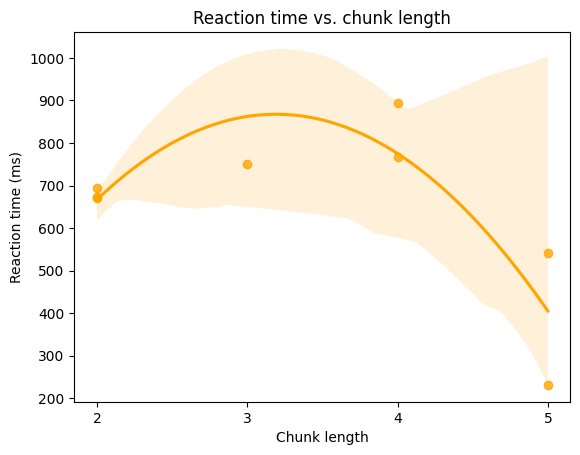

In [86]:
chunk_lengths_hi = df_hiacc.groupby('random_id')['chunk_length'].first()
rt_hi = df_hiacc.groupby('random_id')['rt'].mean()

ax = sns.regplot(x=chunk_lengths_hi, y=rt_hi, order=2, color='orange')
ax.set_xticks(range(2, 6))
ax.set_xlabel("Chunk length")
ax.set_ylabel("Reaction time (ms)")
ax.set_title("Reaction time vs. chunk length")

In [75]:
cl_vs_rt = smf.ols('rt ~ chunk_length + I(chunk_length**2)', data={
    'rt': rt_hi,
    'chunk_length': chunk_lengths_hi,
}).fit()

cl_vs_rt.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     rt   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     6.480
Date:                Wed, 11 Mar 2026   Prob (F-statistic):             0.0409
Time:                        13:17:06   Log-Likelihood:                -47.991
No. Observations:                   8   AIC:                             102.0
Df Residuals:                       5   BIC:                             102.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             -572.7153    487.153     -1.176      0.293   -1824.981     679.551
chunk_length           902.5315    316.116      2.855      0.036      89.930    1715.133
I(chunk_length ** 2)  -141.3973     45.834     -3.085      0.027    -259.217     -23.578
==============================================================================
Omnibus:                        0.287   Durbin-Watson:                   1.452
Prob(Omnibus):                  0.866   Jarque-Bera (JB):                0.336
Skew:                          -0.318   Prob(JB):                        0.845
Kurtosis:                       2.224   Cond. No.                         210.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0.5, 1.0, 'Accuracy vs. chunk length')

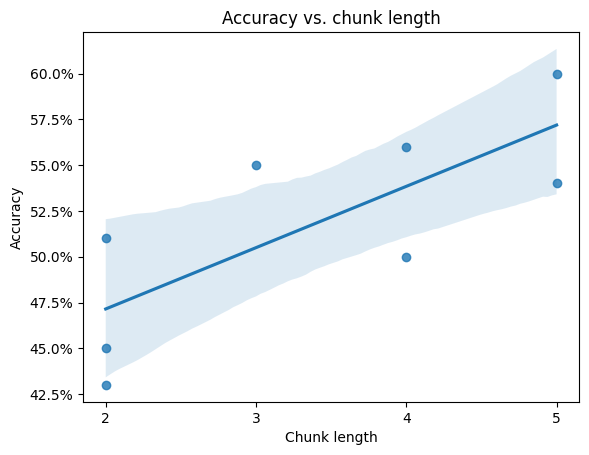

In [ ]:
acc_hi = df_hiacc.groupby('random_id')['won'].mean()
acc_vs_cl = sns.regplot(x=chunk_lengths_hi, y=acc_hi)
acc_vs_cl.set_xticks(range(2, 6))
acc_vs_cl.yaxis.set_major_formatter(PercentFormatter(1.0))
acc_vs_cl.set_xlabel("Chunk length")
acc_vs_cl.set_ylabel("Accuracy")
acc_vs_cl.set_title("Accuracy vs. chunk length")


In [77]:
cl_vs_acc = smf.ols('acc_hi ~ chunk_length', data={
    'acc_hi': acc_hi,
    'chunk_length': chunk_lengths_hi,
}).fit()

cl_vs_acc.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 acc_hi   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     8.453
Date:                Wed, 11 Mar 2026   Prob (F-statistic):             0.0271
Time:                        13:17:06   Log-Likelihood:                 15.616
No. Observations:                   8   AIC:                            -27.23
Df Residuals:                       6   BIC:                            -27.07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.4045      0.041      9.792      0.000       0.303       0.506
chunk_length     0.0335      0.012      2.907      0.027       0.005       0.062
==============================================================================
Omnibus:                        4.850   Durbin-Watson:                   1.954
Prob(Omnibus):                  0.088   Jarque-Bera (JB):                1.063
Skew:                           0.032   Prob(JB):                        0.588
Kurtosis:                       1.215   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

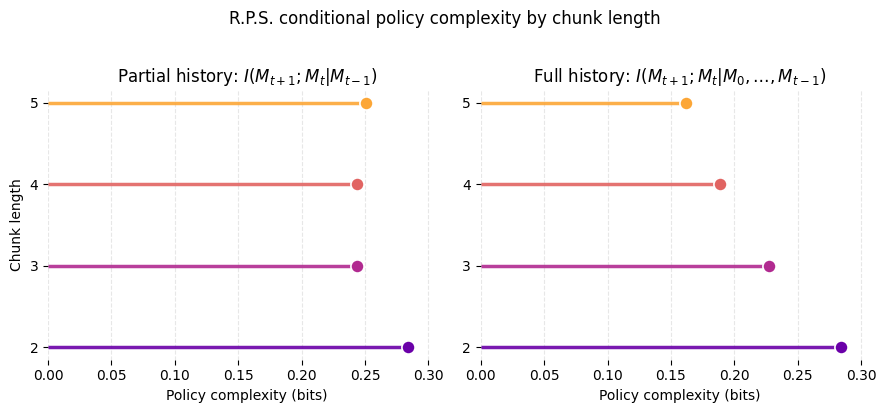

In [90]:
# Policy complexity (as a function of chunk length) conditioned on
#   - partial history (len(h) = 1)
#   - full history (len(h) = inf)

chunk_lengths = np.array(range(2, 6))
cpc_h1 = np.array([0.284, 0.244, 0.244, 0.251])
cpc_hinf = np.array([0.284, 0.227, 0.189, 0.162])

palette = sns.color_palette("plasma", n_colors=len(chunk_lengths))
colors = dict(zip(chunk_lengths, palette))
xmax = max(cpc_h1.max(), cpc_hinf.max()) + 0.03

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
series = [
    (axes[0], cpc_h1, r"Partial history: $I(M_{t+1};M_t|M_{t-1})$"),
    (axes[1], cpc_hinf, r"Full history: $I(M_{t+1};M_t|M_0, \ldots, M_{t-1})$"),
]

for ax, values, title in series:
    for y, x in zip(chunk_lengths, values):
        ax.hlines(y=y, xmin=0, xmax=x, color=colors[y], linewidth=2.5, alpha=0.9)
        ax.scatter(x, y, s=90, color=colors[y], edgecolor="white", linewidth=1.2, zorder=3)

    ax.set_title(title)
    ax.set_xlim(0, xmax)
    ax.set_xlabel("Policy complexity (bits)")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Chunk length")
axes[0].set_yticks(chunk_lengths)
axes[0].set_yticklabels(chunk_lengths)
axes[1].tick_params(axis="y", labelleft=True)
axes[1].set_yticks(chunk_lengths)
axes[1].set_yticklabels(chunk_lengths)

sns.despine(left=True, bottom=True)
fig.suptitle("R.P.S. conditional policy complexity by chunk length", y=1.02)
fig.tight_layout()
